In [9]:
import numpy as np
import torch
from torch import nn
import tqdm

In [10]:
import torchvision
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split


106
12
40


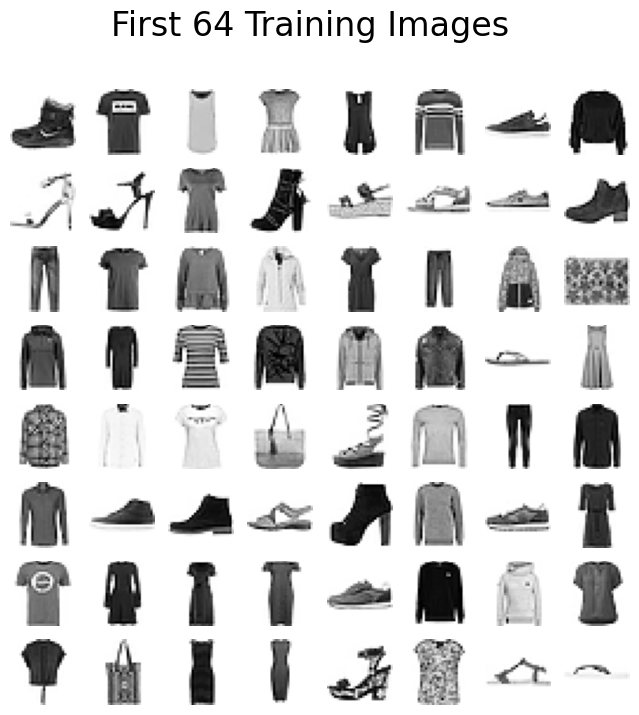

In [11]:
# Use the following code to load and normalize the dataset for training and testing
# It will downlad the dataset into data subfolder (change to your data folder name)
train_dataset = torchvision.datasets.FashionMNIST('data/', train=True, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.2860,), (0.3530,))
                             ]))

test_dataset = torchvision.datasets.FashionMNIST('data/', train=False, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.2860,), (0.3530,))
                             ]))


# Use the following code to create a validation set of 10%
train_indices, val_indices, _, _ = train_test_split(
    range(len(train_dataset)),
    train_dataset.targets,
    stratify=train_dataset.targets,
    test_size=0.1,
)

# Generate training and validation subsets based on indices
train_split = Subset(train_dataset, train_indices)
val_split = Subset(train_dataset, val_indices)


# set batches sizes
train_batch_size = 512 #Define train batch size
test_batch_size  = 256 #Define test batch size (can be larger than train batch size)


# Define dataloader objects that help to iterate over batches and samples for
# training, validation and testing
train_batches = DataLoader(train_split, batch_size=train_batch_size, shuffle=True)
val_batches = DataLoader(val_split, batch_size=train_batch_size, shuffle=True)
test_batches = DataLoader(test_dataset, batch_size=test_batch_size, shuffle=True)
                                           
num_train_batches=len(train_batches)
num_val_batches=len(val_batches)
num_test_batches=len(test_batches)


print(num_train_batches)
print(num_val_batches)
print(num_test_batches)


#Sample code to visulaize the first sample in first 16 batches 

# batch_num = 0
# for train_features, train_labels in train_batches:
    
#     if batch_num == 16:
#         break    # break here
    
#     batch_num = batch_num +1
#     print(f"Feature batch shape: {train_features.size()}")
#     print(f"Labels batch shape: {train_labels.size()}")
    
#     img = train_features[0].squeeze()
#     label = train_labels[0]
#     plt.imshow(img, cmap="gray")
#     plt.show()
#     print(f"Label: {label}")



# Sample code to plot N^2 images from the dataset
def plot_images(XX, N, title):
    fig, ax = plt.subplots(N, N, figsize=(8, 8))
  
    for i in range(N):
      for j in range(N):
        ax[i,j].imshow(XX[(N)*i+j], cmap="Greys")
        ax[i,j].axis("off")
    fig.suptitle(title, fontsize=24)

plot_images(train_dataset.data[:64], 8, "First 64 Training Images" )

    

In [12]:
class Network(nn.Module):
    def __init__(self, input_dim, output_dim, n_hidden_layers=2, hidden_dim=256,
                 use_batch_norm=False, init_method='default'): 
        super().__init__()
        self.use_batch_norm = use_batch_norm
        self.hidden_layers = nn.ModuleList()
        self.bn_layers = nn.ModuleList()

        in_features = input_dim
        for _ in range(n_hidden_layers):
            self.hidden_layers.append(nn.Linear(in_features, hidden_dim))
            if use_batch_norm:
                self.bn_layers.append(nn.BatchNorm1d(hidden_dim))
            in_features = hidden_dim

        self.output_layer = nn.Linear(hidden_dim, output_dim)
        self.relu = nn.ReLU()
        self._init_weights(init_method)

    def _init_weights(self, method):
        for layer in self.hidden_layers:
            if method == 'random_normal':
                nn.init.normal_(layer.weight, mean=0.0, std=0.01)
                nn.init.zeros_(layer.bias)
            elif method == 'xavier':
                nn.init.xavier_normal_(layer.weight)
                nn.init.zeros_(layer.bias)
            elif method == 'kaiming':
                nn.init.kaiming_uniform_(layer.weight, nonlinearity='relu')
                nn.init.zeros_(layer.bias)

    def forward(self, input):
        x = input
        for i, layer in enumerate(self.hidden_layers):
            x = layer(x)
            if self.use_batch_norm:
                x = self.bn_layers[i](x)
            x = self.relu(x)
        return self.output_layer(x)


In [ ]:
# Initialize neural network model with input, output and hidden layer dimensions
model = Network(input_dim=784, output_dim=10, n_hidden_layers=2, hidden_dim=256) 
                
learning_rate = 0.1
epochs = 5


train_loss_list = np.zeros((epochs,))
validation_accuracy_list = np.zeros((epochs,))
validation_loss_list = np.zeros((epochs,))

loss_func = nn.CrossEntropyLoss()  
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)


for epoch in tqdm.trange(epochs):

    # Network Training 
    epoch_loss = 0.0
    for train_features, train_labels in train_batches:
        model.train()
        
        train_features = train_features.reshape(-1, 28*28)

   
        optimizer.zero_grad()
        outputs = model(train_features)
        loss = loss_func(outputs, train_labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
 
    train_loss_list[epoch] = epoch_loss / num_train_batches
    
    val_acc = 0.0
    val_loss = 0.0
    for val_features, val_labels in val_batches:
        
        with torch.no_grad(): 
            model.eval()
            
            val_features = val_features.reshape(-1, 28*28)
          
        
            val_outputs = model(val_features)
            val_predictions = val_outputs.argmax(dim=1)
            val_acc += (val_predictions == val_labels).float().mean().item()
            val_loss += loss_func(val_outputs, val_labels).item()
            
    validation_accuracy_list[epoch] = val_acc / num_val_batches
    validation_loss_list[epoch] = val_loss / num_val_batches
    print("Epoch: "+ str(epoch) +"; Train Loss: " + f"{train_loss_list[epoch]:.4f}"
          + "; Val Loss: " + f"{validation_loss_list[epoch]:.4f}"
          + "; Validation Accuracy:" + str(val_acc/num_val_batches*100) + '%')


 20%|██        | 1/5 [00:22<01:30, 22.62s/it]

Epoch: 0; Train Loss: 0.7086; Val Loss: 0.4294; Validation Accuracy:84.32758698860803%


 40%|████      | 2/5 [00:42<01:03, 21.25s/it]

Epoch: 1; Train Loss: 0.3813; Val Loss: 0.3542; Validation Accuracy:87.01313386360803%


 60%|██████    | 3/5 [01:02<00:41, 20.54s/it]

Epoch: 2; Train Loss: 0.3305; Val Loss: 0.3804; Validation Accuracy:86.29557291666666%


 80%|████████  | 4/5 [01:22<00:20, 20.24s/it]

Epoch: 3; Train Loss: 0.3126; Val Loss: 0.3320; Validation Accuracy:87.25869009892145%


100%|██████████| 5/5 [01:41<00:00, 20.35s/it]

Epoch: 4; Train Loss: 0.2891; Val Loss: 0.3237; Validation Accuracy:87.72149582703909%


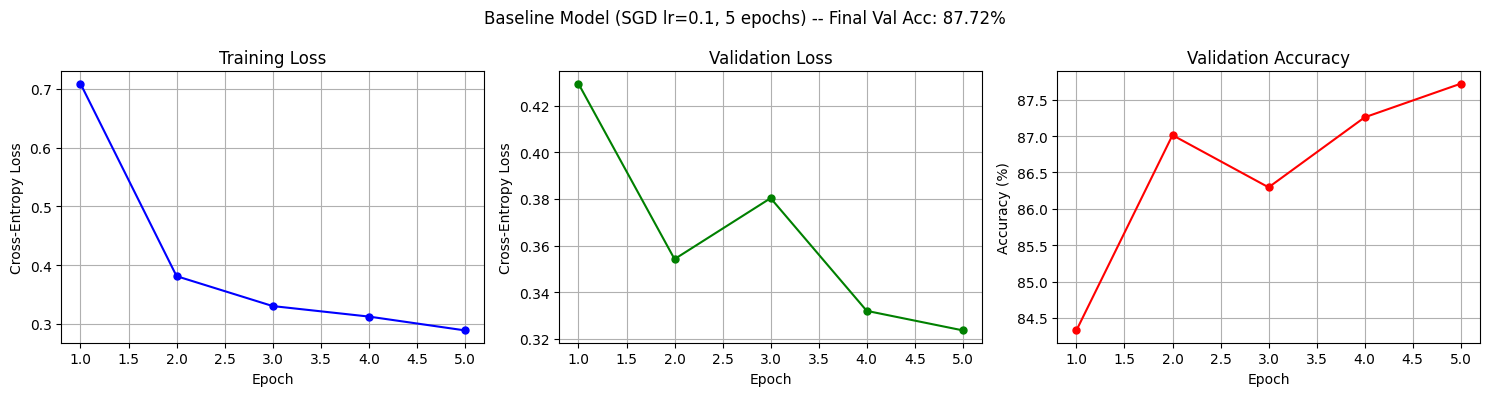

In [14]:
# Plot training loss and validation accuracy throughout the training epochs
epochs_range = np.arange(1, epochs + 1)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

ax1.plot(epochs_range, train_loss_list, 'b-o', markersize=5)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.set_title('Training Loss')
ax1.grid(True)

ax2.plot(epochs_range, validation_loss_list, 'g-o', markersize=5)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Cross-Entropy Loss')
ax2.set_title('Validation Loss')
ax2.grid(True)

ax3.plot(epochs_range, validation_accuracy_list * 100, 'r-o', markersize=5)
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Accuracy (%)')
ax3.set_title('Validation Accuracy')
ax3.grid(True)

plt.suptitle(f'Baseline Model (SGD lr={learning_rate}, {epochs} epochs) '
             f'-- Final Val Acc: {validation_accuracy_list[-1]*100:.2f}%')
plt.tight_layout()
plt.savefig('baseline_curves.png', dpi=150, bbox_inches='tight')
plt.show()


In [15]:
#Calculate accuracy on test set

with torch.no_grad():
    test_acc = 0.0
    test_acc_batches = []
    
    for test_features, test_labels in test_batches:

        model.eval()
        test_features = test_features.reshape(-1, 28*28)


        test_outputs = model(test_features)
        test_predictions = test_outputs.argmax(dim=1)
        batch_acc = (test_predictions == test_labels).float().mean().item()
        test_acc += batch_acc
        test_acc_batches.append(batch_acc)
    
    
    mean_test_acc = test_acc / num_test_batches * 100
    std_test_acc  = np.std(test_acc_batches) * 100
    print(f'Test Accuracy: {mean_test_acc:.2f}% +/- {std_test_acc:.2f}%')


Test Accuracy: 87.00% +/- 2.54%


SGD lr=0.01: Test Acc = 86.88%


SGD lr=0.1 (baseline): Test Acc = 88.29%


RMSProp lr=0.001: Test Acc = 87.82%


RMSProp lr=0.01: Test Acc = 83.50%


Adam lr=0.0001: Test Acc = 86.27%


Adam lr=0.001: Test Acc = 88.62%


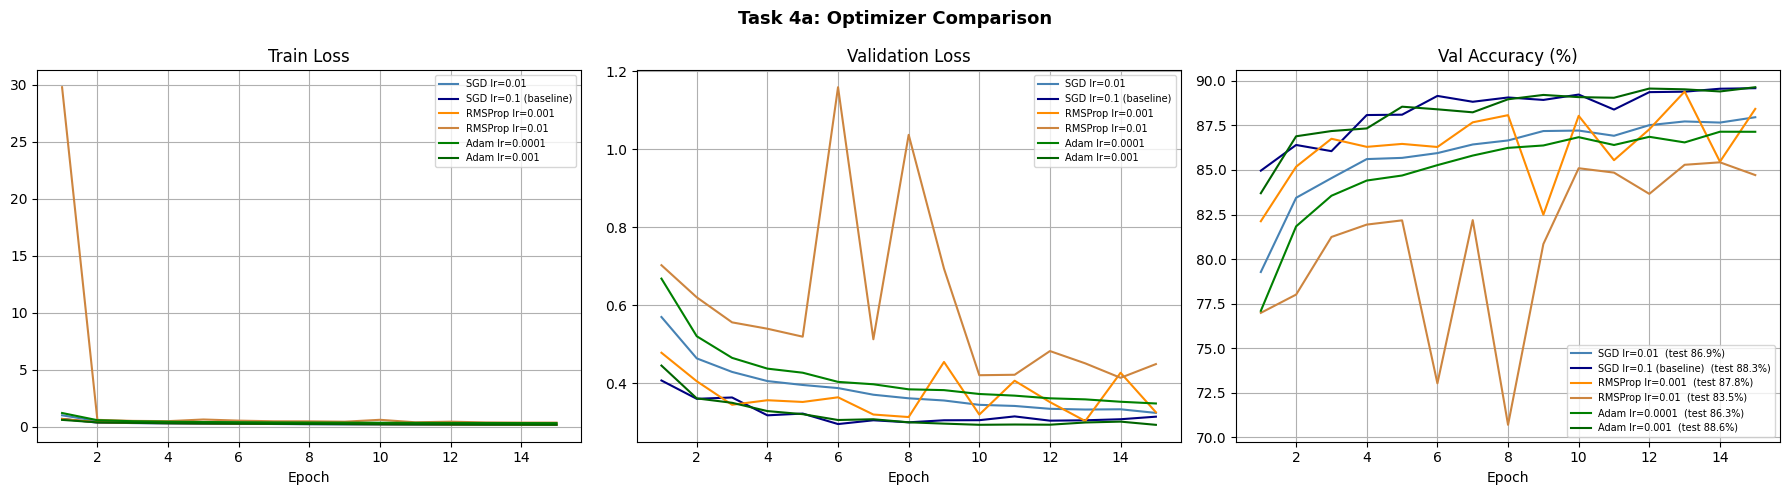

Config                      Test Acc   Final Val Acc
-----------------------------------------------------
SGD lr=0.01                   86.88%          87.96%
SGD lr=0.1 (baseline)         88.29%          89.59%
RMSProp lr=0.001              87.82%          88.43%
RMSProp lr=0.01               83.50%          84.71%
Adam lr=0.0001                86.27%          87.14%
Adam lr=0.001                 88.62%          89.64%


PyTorch Default (Kaiming Uniform): Test Acc = 88.29%


Random Normal (std=0.01): Test Acc = 88.64%


Xavier Normal: Test Acc = 88.28%


Kaiming (He) Uniform: Test Acc = 88.13%


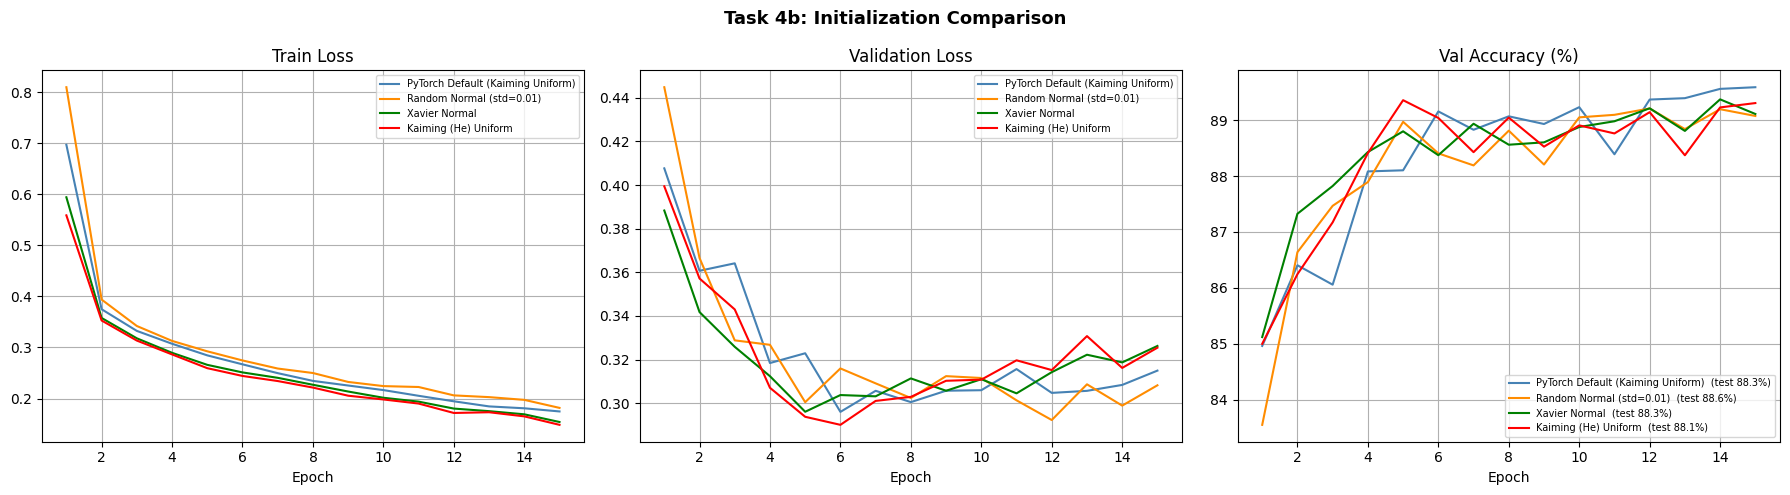

Config                                   Test Acc   Final Val Acc
------------------------------------------------------------------
PyTorch Default (Kaiming Uniform)          88.29%          89.59%
Random Normal (std=0.01)                   88.64%          89.07%
Xavier Normal                              88.28%          89.11%
Kaiming (He) Uniform                       88.13%          89.31%


No BatchNorm: Test Acc = 88.29%


With BatchNorm: Test Acc = 88.67%


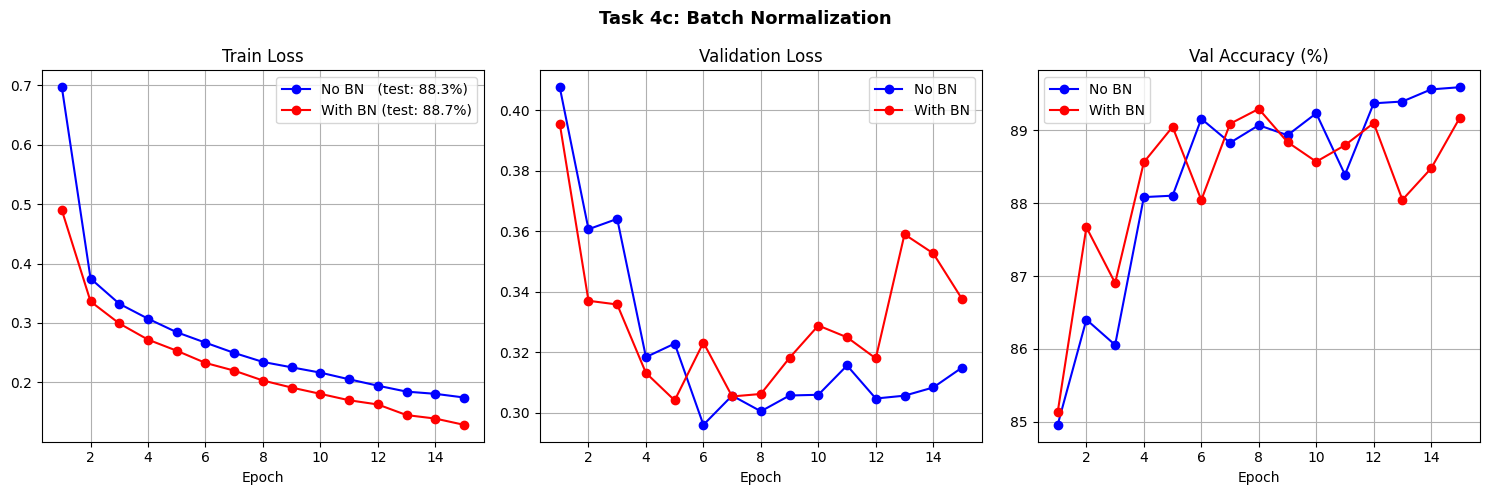

Without BatchNorm -- Test Accuracy: 88.29%
With    BatchNorm -- Test Accuracy: 88.67%


In [16]:
# Task 4 Helper: reusable training function

def run_experiment(n_hidden_layers=2, hidden_dim=256, learning_rate=0.1,
                   epochs=15, optimizer_name='SGD',
                   use_batch_norm=False, init_method='default', label=''):
    torch.manual_seed(42)
    m = Network(input_dim=784, output_dim=10,
                n_hidden_layers=n_hidden_layers, hidden_dim=hidden_dim,
                use_batch_norm=use_batch_norm, init_method=init_method)

    loss_fn = nn.CrossEntropyLoss()
    if optimizer_name == 'SGD':
        opt = torch.optim.SGD(m.parameters(), lr=learning_rate, momentum=0.9)
    elif optimizer_name == 'Adam':
        opt = torch.optim.Adam(m.parameters(), lr=learning_rate)
    elif optimizer_name == 'RMSProp':
        opt = torch.optim.RMSprop(m.parameters(), lr=learning_rate)

    tr_loss  = np.zeros(epochs)
    val_loss = np.zeros(epochs)
    val_acc_arr = np.zeros(epochs)

    for epoch in tqdm.trange(epochs, desc=label, leave=False):
        m.train()
        ep_loss = 0.0
        for xb, yb in train_batches:
            xb = xb.reshape(-1, 28*28)
            opt.zero_grad()
            l = loss_fn(m(xb), yb)
            l.backward()
            opt.step()
            ep_loss += l.item()
        tr_loss[epoch] = ep_loss / num_train_batches

        m.eval()
        acc = 0.0
        vl  = 0.0
        with torch.no_grad():
            for xv, yv in val_batches:
                xv = xv.reshape(-1, 28*28)
                out = m(xv)
                acc += (out.argmax(1) == yv).float().mean().item()
                vl  += loss_fn(out, yv).item()
        val_acc_arr[epoch] = acc / num_val_batches
        val_loss[epoch]    = vl  / num_val_batches

    m.eval()
    tacc = 0.0
    with torch.no_grad():
        for xt, yt in test_batches:
            xt = xt.reshape(-1, 28*28)
            tacc += (m(xt).argmax(1) == yt).float().mean().item()
    test_acc = tacc / num_test_batches * 100
    print(f'{label}: Test Acc = {test_acc:.2f}%')
    return {'train_loss': tr_loss, 'val_loss': val_loss,
            'val_acc': val_acc_arr, 'test_accuracy': test_acc}


# Task 4a: Optimizer Comparison (SGD, Adam, RMSProp)

n_epochs = 15

optimizer_configs = [
    ('SGD',      0.01,   'SGD lr=0.01'),
    ('SGD',      0.1,    'SGD lr=0.1 (baseline)'),
    ('RMSProp',  0.001,  'RMSProp lr=0.001'),
    ('RMSProp',  0.01,   'RMSProp lr=0.01'),
    ('Adam',     0.0001, 'Adam lr=0.0001'),
    ('Adam',     0.001,  'Adam lr=0.001'),
]

opt_results = {}
for opt_name, lr, lbl in optimizer_configs:
    opt_results[lbl] = run_experiment(learning_rate=lr, optimizer_name=opt_name,
                                      epochs=n_epochs, label=lbl)

epochs_range = np.arange(1, n_epochs + 1)
colors = ['steelblue','navy','darkorange','peru','green','darkgreen']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for (lbl, res), c in zip(opt_results.items(), colors):
    axes[0].plot(epochs_range, res['train_loss'], color=c, label=lbl)
    axes[1].plot(epochs_range, res['val_loss'],   color=c, label=lbl)
    axes[2].plot(epochs_range, res['val_acc']*100, color=c,
                 label=f"{lbl}  (test {res['test_accuracy']:.1f}%)")
axes[0].set_title('Train Loss');       axes[0].set_xlabel('Epoch'); axes[0].grid(True); axes[0].legend(fontsize=7)
axes[1].set_title('Validation Loss');  axes[1].set_xlabel('Epoch'); axes[1].grid(True); axes[1].legend(fontsize=7)
axes[2].set_title('Val Accuracy (%)'); axes[2].set_xlabel('Epoch'); axes[2].grid(True); axes[2].legend(fontsize=7)
plt.suptitle('Task 4a: Optimizer Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('optimizer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"{'Config':<25} {'Test Acc':>10}  {'Final Val Acc':>14}")
print('-' * 53)
for lbl, res in opt_results.items():
    print(f"{lbl:<25} {res['test_accuracy']:>9.2f}%  {res['val_acc'][-1]*100:>13.2f}%")


# Task 4b: Initialization Comparison

init_configs = [
    ('default',       'PyTorch Default (Kaiming Uniform)'),
    ('random_normal', 'Random Normal (std=0.01)'),
    ('xavier',        'Xavier Normal'),
    ('kaiming',       'Kaiming (He) Uniform'),
]

init_results = {}
for method, lbl in init_configs:
    init_results[lbl] = run_experiment(init_method=method, epochs=n_epochs, label=lbl)

colors4 = ['steelblue','darkorange','green','red']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for (lbl, res), c in zip(init_results.items(), colors4):
    axes[0].plot(epochs_range, res['train_loss'], color=c, label=lbl)
    axes[1].plot(epochs_range, res['val_loss'],   color=c, label=lbl)
    axes[2].plot(epochs_range, res['val_acc']*100, color=c,
                 label=f"{lbl}  (test {res['test_accuracy']:.1f}%)")
axes[0].set_title('Train Loss');       axes[0].set_xlabel('Epoch'); axes[0].grid(True); axes[0].legend(fontsize=7)
axes[1].set_title('Validation Loss');  axes[1].set_xlabel('Epoch'); axes[1].grid(True); axes[1].legend(fontsize=7)
axes[2].set_title('Val Accuracy (%)'); axes[2].set_xlabel('Epoch'); axes[2].grid(True); axes[2].legend(fontsize=7)
plt.suptitle('Task 4b: Initialization Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('init_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"{'Config':<38} {'Test Acc':>10}  {'Final Val Acc':>14}")
print('-' * 66)
for lbl, res in init_results.items():
    print(f"{lbl:<38} {res['test_accuracy']:>9.2f}%  {res['val_acc'][-1]*100:>13.2f}%")


# Task 4c: Batch Normalization

no_bn   = run_experiment(use_batch_norm=False, epochs=n_epochs, label='No BatchNorm')
with_bn = run_experiment(use_batch_norm=True,  epochs=n_epochs, label='With BatchNorm')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].plot(epochs_range, no_bn['train_loss'],   'b-o', label=f"No BN   (test: {no_bn['test_accuracy']:.1f}%)")
axes[0].plot(epochs_range, with_bn['train_loss'],  'r-o', label=f"With BN (test: {with_bn['test_accuracy']:.1f}%)")
axes[1].plot(epochs_range, no_bn['val_loss'],   'b-o', label='No BN')
axes[1].plot(epochs_range, with_bn['val_loss'],  'r-o', label='With BN')
axes[2].plot(epochs_range, no_bn['val_acc']*100,   'b-o', label='No BN')
axes[2].plot(epochs_range, with_bn['val_acc']*100,  'r-o', label='With BN')
axes[0].set_title('Train Loss');       axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True)
axes[1].set_title('Validation Loss');  axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True)
axes[2].set_title('Val Accuracy (%)'); axes[2].set_xlabel('Epoch'); axes[2].legend(); axes[2].grid(True)
plt.suptitle('Task 4c: Batch Normalization', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('batchnorm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Without BatchNorm -- Test Accuracy: {no_bn['test_accuracy']:.2f}%")
print(f"With    BatchNorm -- Test Accuracy: {with_bn['test_accuracy']:.2f}%")
